#### Imports

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import readsav
from pathlib import Path
from scipy.fft import fft, ifft
import kneed
import maos_utils as mu
from pathlib import Path

#### Load LGS telemetry files

In [45]:
# Fetch names of all 'LGS' telemetry files
telem_home = Path("/g/lu/data/keck_telemetry/")
paths = [f.as_posix() for f in telem_home.glob(f"*/sdata90*/nirc*/*/n*_LGS_trs.sav")]
data_list = []
phibar = np.empty(len(paths[:-1:100]))
telem_phibar = np.empty(len(paths[:-1:100]))
phi_func_t = []
residual_rms_func_t = []
for i, path in enumerate(paths[:-1:100]):
    print(f"{path}")
    # data = readsav(path)
    # data_list.append(data)

    # Calculate RMS WFE 
    phi, phi_t, telem_residual_rms = mu.centroid_residual_to_RMSWFE(path)
    phibar[i] = phi
    telem_phibar[i] = np.mean(telem_residual_rms)
    phi_func_t.append(phi_t)
    residual_rms_func_t.append(telem_residual_rms)


/g/lu/data/keck_telemetry/20170718/sdata901/nirc15/2017jul18/n0098_LGS_trs.sav
/g/lu/data/keck_telemetry/20170504/sdata903/nirc15/2017may04/n0051_LGS_trs.sav
/g/lu/data/keck_telemetry/20170504/sdata903/nirc15/2017may04/n0151_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0229_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0329_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0035_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0135_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0235_LGS_trs.sav
/g/lu/data/keck_telemetry/20170727/sdata902/nirc20/2017jul27/n0590_LGS_trs.sav
/g/lu/data/keck_telemetry/20170727/sdata902/nirc20/2017jul27/n0690_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017aug08/n0110_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017aug08/n0210_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017

In [12]:
# telem = Path("/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0060_LGS_trs.sav") #c0103, c0104, c0105, c0107
# data = readsav("/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0060_LGS_trs.sav")
# data.header

In [31]:
# Purely for plotting purposes: 
SMALL_SIZE = 10
MEDIUM_SIZE = 11
BIGGER_SIZE = 13

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### **RMS WFE from centroid offsets ( ``mu.centroid_residual_to_RMSWFE(...)`` )**

The following plot is supposed to have units of nanometers on the x-axis, but something seems wrong with the calculation because the errors are too high

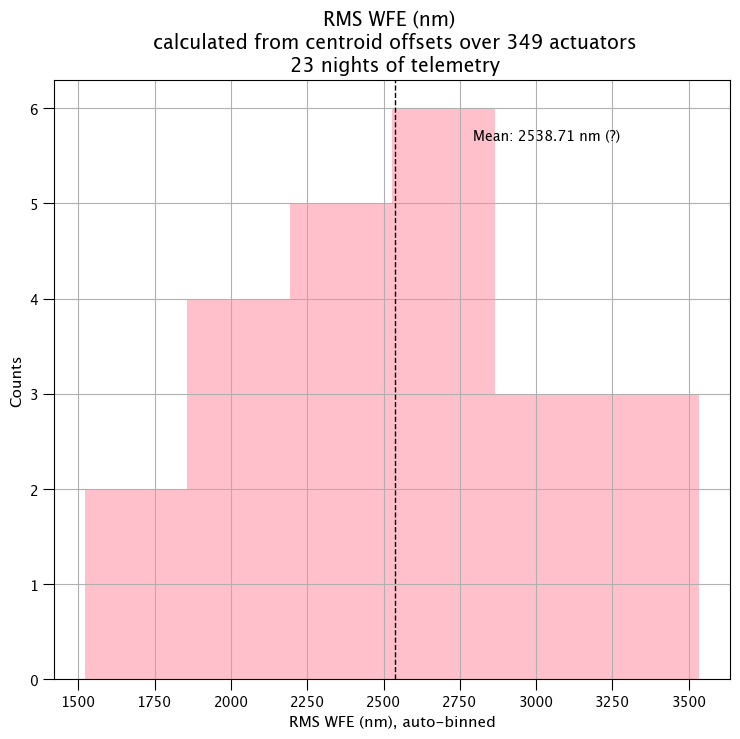

In [54]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.hist(phibar, bins='auto', color='pink') 
plt.title(f"RMS WFE (nm) \n calculated from centroid offsets over 349 actuators\n {len(paths[:-1:100])} nights of telemetry", fontsize=14)
plt.axvline(phibar.mean(), color='k', linestyle='dashed', linewidth=1)
plt.xlabel("RMS WFE (nm), auto-binned")
plt.ylabel("Counts")
plt.tight_layout()
plt.grid(True)

min_ylim, max_ylim = plt.ylim()
plt.text(phibar.mean()*1.1, max_ylim*0.9, 'Mean: {:.2f} nm (?)'.format(phibar.mean()))
plt.show()

##### **``data.a.residualrms``**

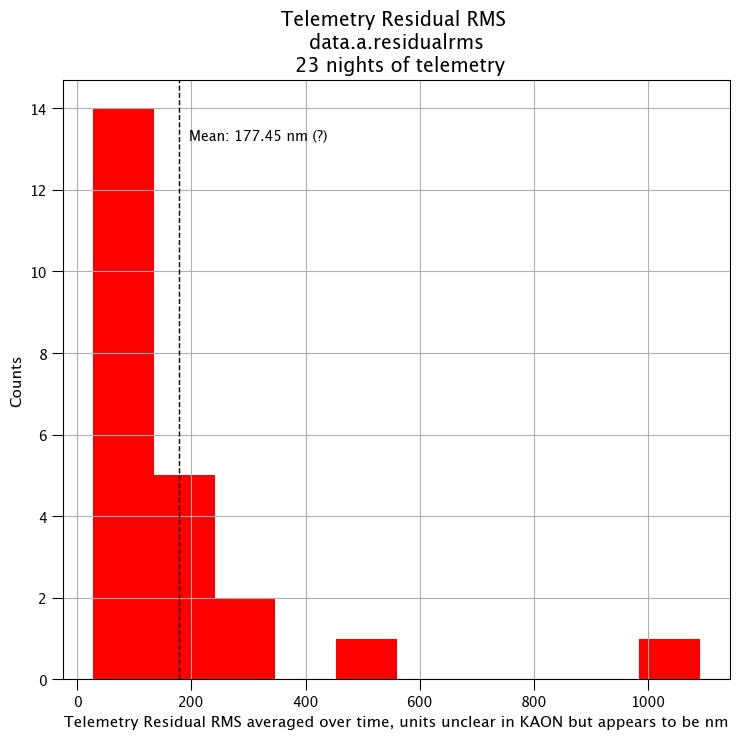

In [56]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.hist(telem_phibar, bins='auto', color='red') 
plt.title(f"Telemetry Residual RMS \n data.a.residualrms \n {len(paths[:-1:100])} nights of telemetry", fontsize=14)
plt.axvline(telem_phibar.mean(), color='k', linestyle='dashed', linewidth=1)
plt.xlabel("Telemetry Residual RMS averaged over time, units unclear in KAON but appears to be nm")
plt.ylabel("Counts")
plt.tight_layout()
min_ylim, max_ylim = plt.ylim()
plt.text(telem_phibar.mean()*1.1, max_ylim*0.9, 'Mean: {:.2f} nm (?)'.format(telem_phibar.mean()))
plt.grid(True)
plt.show()

In [ ]:
fig, axes = plt.subplots(figsize=(17.5, 5))
for i in range(len(residual_rms_func_t)):
    plt.plot(residual_rms_func_t[i])
plt.tight_layout()
plt.grid(True)
plt.show()

#### 'Knee' frequencies

where break in power spectra (FFT) of telemetry streams occurs

In [13]:
# # Collect telemetry durations and average time spacing for A and B objects
# # within each data object
# time_data = np.empty((len(data_list), 3))
# for i, data in enumerate(data_list):
#     start_time = data.a.timestamp[0][0] * 100.0 # in ns
#     stop_time = data.a.timestamp[0][-1] * 100.0 # in ns
#     tint = (stop_time - start_time) * 1.0e-9
#     # Store duration of telemetry in seconds
#     time_data[i][0] = tint
#     # Average data.b time spacing 
#     time_data[i][1] = np.mean(np.diff(data.b.timestamp[0])) * 100.0 * (1e-9) # seconds
#     # Average data.a time spacing
#     time_data[i][2] = np.mean(np.diff(data.a.timestamp[0])) * 100.0 * (1e-9) # seconds

In [64]:
# Grab actual telemetry data objects
data_list = []
for i, path in enumerate(paths[:-1:100]):
    print(f"{path}")
    data = readsav(path)
    data_list.append(data)

/g/lu/data/keck_telemetry/20170718/sdata901/nirc15/2017jul18/n0098_LGS_trs.sav
/g/lu/data/keck_telemetry/20170504/sdata903/nirc15/2017may04/n0051_LGS_trs.sav
/g/lu/data/keck_telemetry/20170504/sdata903/nirc15/2017may04/n0151_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0229_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0329_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0035_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0135_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0235_LGS_trs.sav
/g/lu/data/keck_telemetry/20170727/sdata902/nirc20/2017jul27/n0590_LGS_trs.sav
/g/lu/data/keck_telemetry/20170727/sdata902/nirc20/2017jul27/n0690_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017aug08/n0110_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017aug08/n0210_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017

In [ ]:
# According to KAON 1165 AO Telemetry, DTTCENTROIDS is a measure of the TT 
# residual in arcsec
ttcentroids_x = data.b.dttcentroids[0][:,0]
ttcentroids_y = data.b.dttcentroids[0][:,1]

In [ ]:
# indices = np.argsort(freq)[:100]
# S = Sensitivity = 1.0 as suggested by kneed docs, concave curve to locate knee point, increasing direction for positive slope
kneedle_pol = kneed.KneeLocator(freq, np.abs(tt_pol_ffty), S=1.0, curve='convex', 
                            direction='decreasing', interp_method='polynomial', 
                            polynomial_degree=6)
kneedle_cl = kneed.KneeLocator(freq, np.abs(ttcentroids_ffty), S=1.0, curve='concave', 
                            direction='increasing', interp_method='polynomial', 
                            polynomial_degree=8)
elbow = kneedle_pol.elbow # the returned knee point is the value on the x-axis (frequency)
print(f'Elbow using pseudo-open-loop curve: {elbow} Hz')
knee = kneedle_cl.knee
print(f'Knee using closed-loop curve: {knee} Hz')
kneedle_pol.plot_knee_normalized(title='Pseudo Open Loop')
kneedle_cl.plot_knee_normalized(title='Closed Loop')

plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.semilogy(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.axvline(x=elbow, linestyle='--', color='black')
plt.axvline(x=knee, linestyle='-.', color='black')
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

### Calculate RMS Wavefront Error
using equation 8 from https://opg.optica.org/oe/fulltext.cfm?uri=oe-32-1-301&id=54465, implemented in MAOS_UTILS

### Plot RMS Residuals for SHWFS 

In [290]:

for i, data in enumerate(data_list):
    residualwavefrnt = np.transpose(data.a.residualwavefront[0])
    residualwavefrnt[0]

array([1.5498906 , 1.3510566 , 0.7784645 , ..., 1.7675025 , 0.79494905,
       1.4993864 ], dtype=float32)

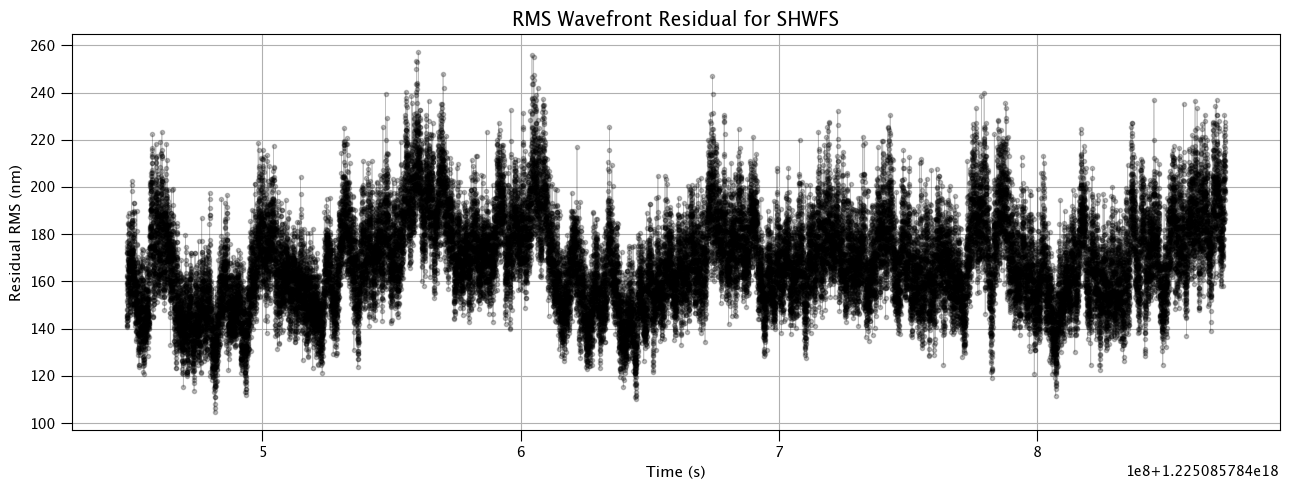

In [231]:
fig, axes = plt.subplots(figsize=(13, 5))
plt.plot(data.a.timestamp[0], data.a.residualrms[0][0], '.-', linewidth=0.5, alpha=0.25, color="black")
plt.title(f"RMS Wavefront Residual for SHWFS", fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Residual RMS (nm)')
plt.tight_layout()
plt.grid(True)
plt.show()

**Tip-Tilt Validation**

KAON 1165 AO Telemetry 4 PSF-R file states that the four entries for each subarray in the apdcounts data below correspond to the "four quadrants." The telemetry colab notebook states:

For each telemetry files, we get out one number for each entry by averaging over timestamps and(or) averaging over space:
- residual_rms: average over timestamps
- residual_rms_std: average over timestamps
- apd_counts & apd_counts_std: first average over space, then over timestamps

I am assuming the "averaging over space" for the apdcounts data is averaging over the four quadrants referenced in the KAON (WFS divided into four quadrants).

In [232]:
# Apdcounts for TT sensor to validate TT brightness input into MAOS
data.b.apdcounts[0]

array([[253., 305., 198., 257.],
       [230., 274., 243., 303.],
       [195., 281., 234., 247.],
       ...,
       [223., 272., 232., 287.],
       [220., 288., 245., 284.],
       [205., 274., 228., 294.]], dtype=float32)

In [233]:
# Average apdcounts over space and then over time
space_avg = np.mean(data.b.apdcounts[0], axis=1)
np.mean(space_avg)

247.75195

Unit for this data is simply "counts." powfs.siglev for c0103 is [1270 1621 3723], where the second entry corresponds to the signal level (e.g. brightness) for STRAP, the TT WFS. 

In [234]:
data.header[-3]

b"STAPDQMN= '62635.500         ' / STRAP Quad Mean APD counts (co                 "

In [235]:
# According to KAON 1165 AO Telemetry, DTTCENTROIDS is a measure of the TT 
# residual in arcsec
ttcentroids_x = data.b.dttcentroids[0][:,0]
ttcentroids_y = data.b.dttcentroids[0][:,1]

RESIDUALWAVEFRONT

[0:348, *]   : residuals at the 349 actuators | Volts (volts-2-micron conversion factor is 0.6 microns/volt)

[349:350, *] : residual tip/tilt              | arcsec

[351, *]     : residual defocus               | microns



In [236]:
# According to KAON 1165, RESIDUALWAVEFRONT is the residual wavefront in various units (see above),
# but shape of data.a.residualwavefront[0] is (42516, 352), so flipped from expectation of
# document

# measurement source is from laser, not from NGS on TT sensor, hence why it lives in data.a
tt_residual = data.a.residualwavefront[0][:, 349:350] 

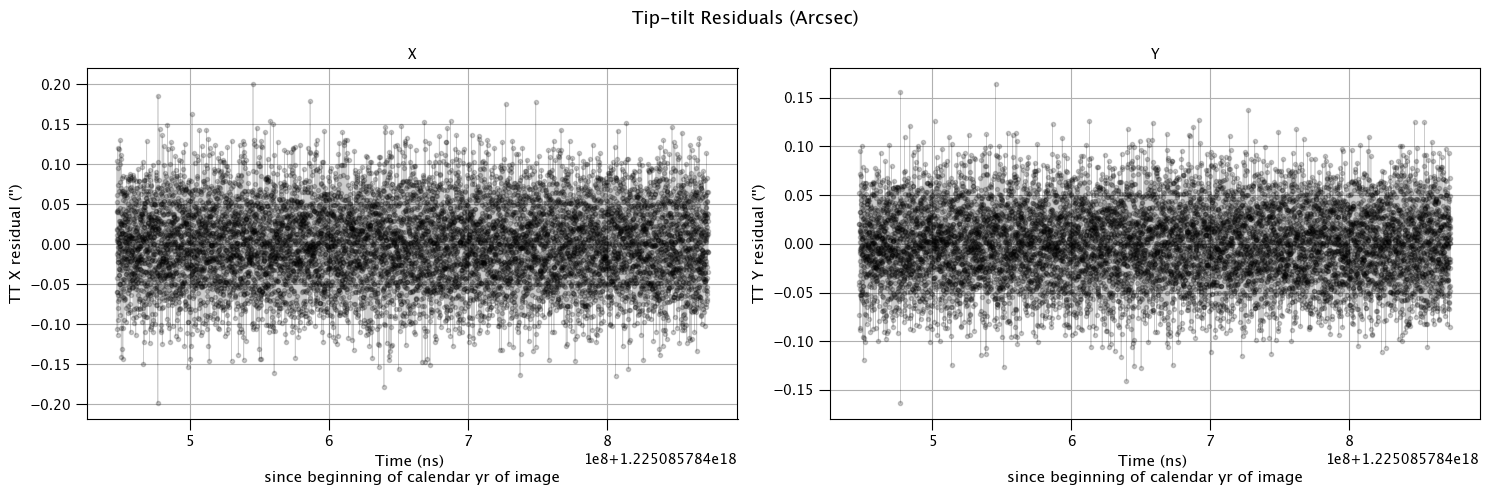

In [237]:
# Plot tip tilt centroid offsets
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].grid(True)
axes[1].grid(True)
axes[0].plot(data.b.timestamp[0], ttcentroids_x, 'k.-', linewidth=0.5, alpha=0.2)
axes[1].plot(data.b.timestamp[0], ttcentroids_y, 'k.-', linewidth=0.5, alpha=0.2)
axes[0].set_xlabel(f"Time (ns) \nsince beginning of calendar yr of image")
axes[1].set_xlabel(f"Time (ns) \nsince beginning of calendar yr of image")
axes[0].set_ylabel("TT X residual ('')")
axes[1].set_ylabel("TT Y residual ('')")
axes[0].set_title("X")
axes[1].set_title("Y")
fig.suptitle("Tip-tilt Residuals (Arcsec)")
plt.tight_layout()

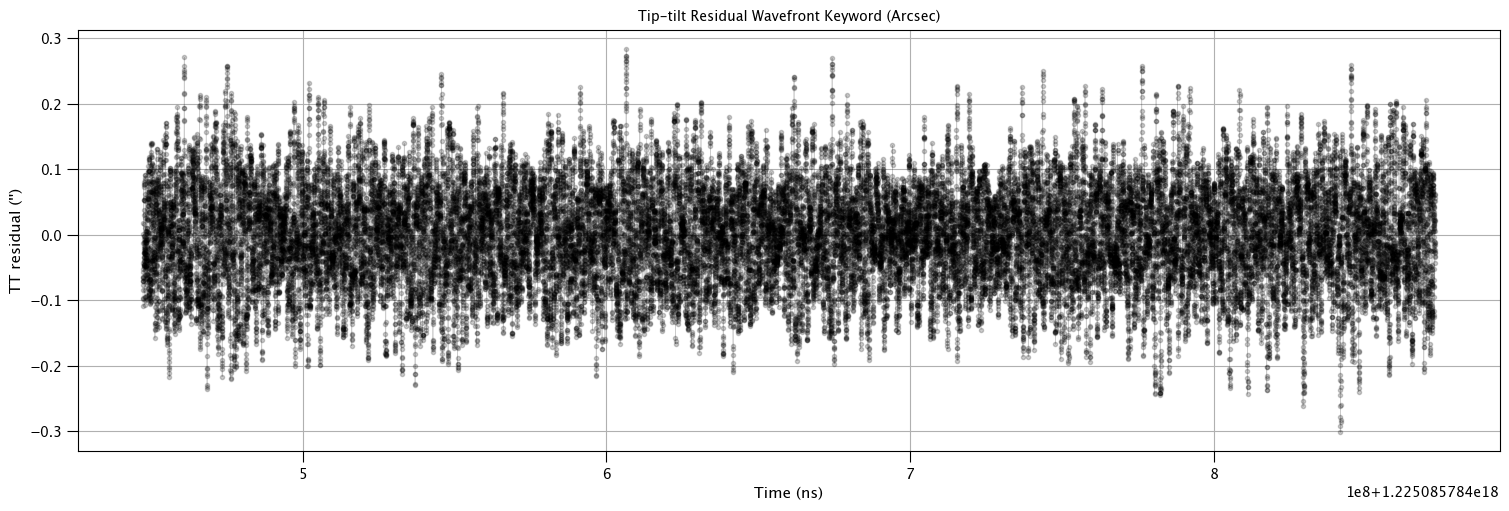

In [238]:
fig, axes = plt.subplots(figsize=(15, 5))
plt.plot(data.a.timestamp[0], tt_residual, 'k.-', alpha=0.2, linewidth=0.5)
plt.tight_layout()
plt.xlabel("Time (ns)")
plt.ylabel("TT residual ('')")
plt.title("Tip-tilt Residual Wavefront Keyword (Arcsec)")
plt.grid(True)

**X Tip-Tilt Power Spectrum**

In [257]:
# Fourier transform TT centroids x
n = len(ttcentroids_x)
# ttcentroids_fftx = fft(ttcentroids_x)
# Real Fourier transform TT centroids (x) into frequency space
ttcentroids_fftx = np.fft.rfft(ttcentroids_x)
# Grab real (non-negative) frequencies
freq = np.fft.rfftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)

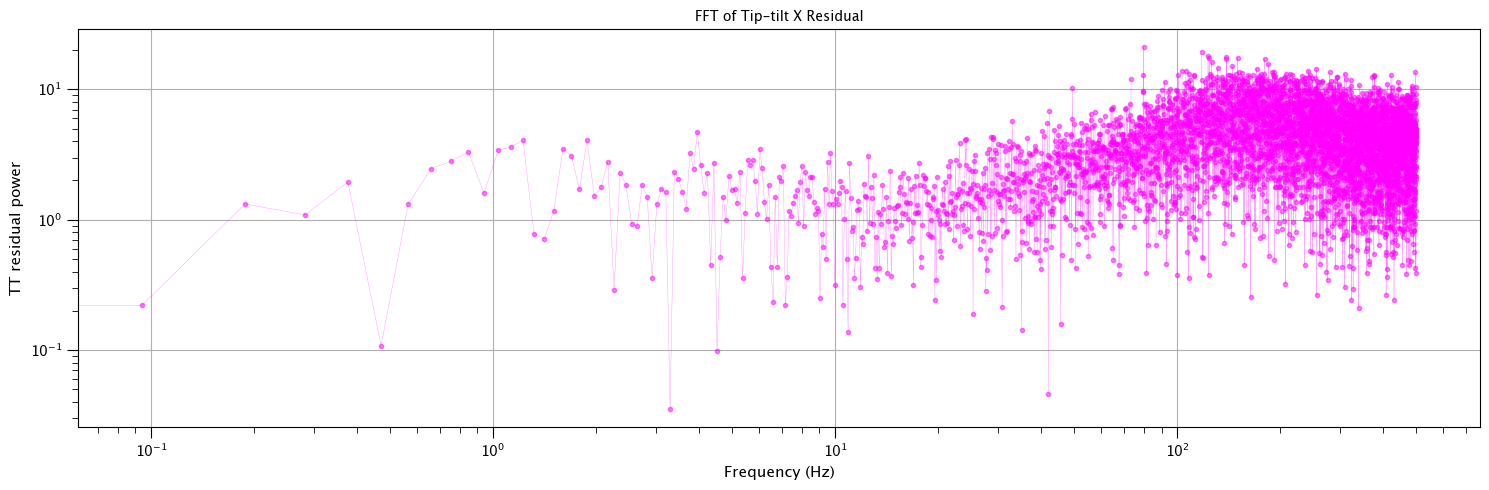

In [258]:
plt.figure(figsize=(15, 5))
plt.loglog(freq, np.abs(ttcentroids_fftx), '.-', linewidth=0.25, color="magenta", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt X Residual")
plt.grid(True)
plt.tight_layout()

**Y Tip-Tilt Power Spectrum**

In [241]:
# Fourier transform TT centroids y
n = len(ttcentroids_y)
# Real Fourier transform TT centroids (y) into frequency space
ttcentroids_ffty = np.fft.rfft(ttcentroids_y)
# Grab real (non-negative) frequencies
freq = np.fft.rfftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)
pos_freq = freq

print(ttcentroids_y.shape)
print(ttcentroids_ffty.shape)
print(freq.shape)

(10629,)
(5315,)
(5315,)


(0.0, 75.0)

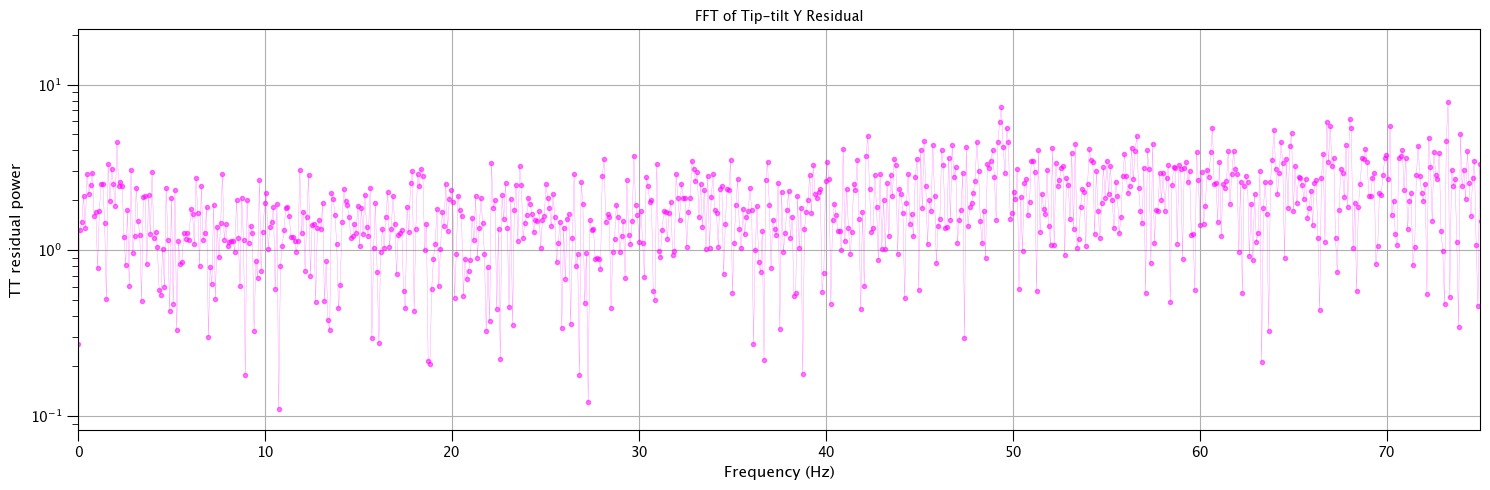

In [265]:
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Y Residual")
plt.grid(True)
plt.tight_layout()
plt.xlim(0.0, 75.0)

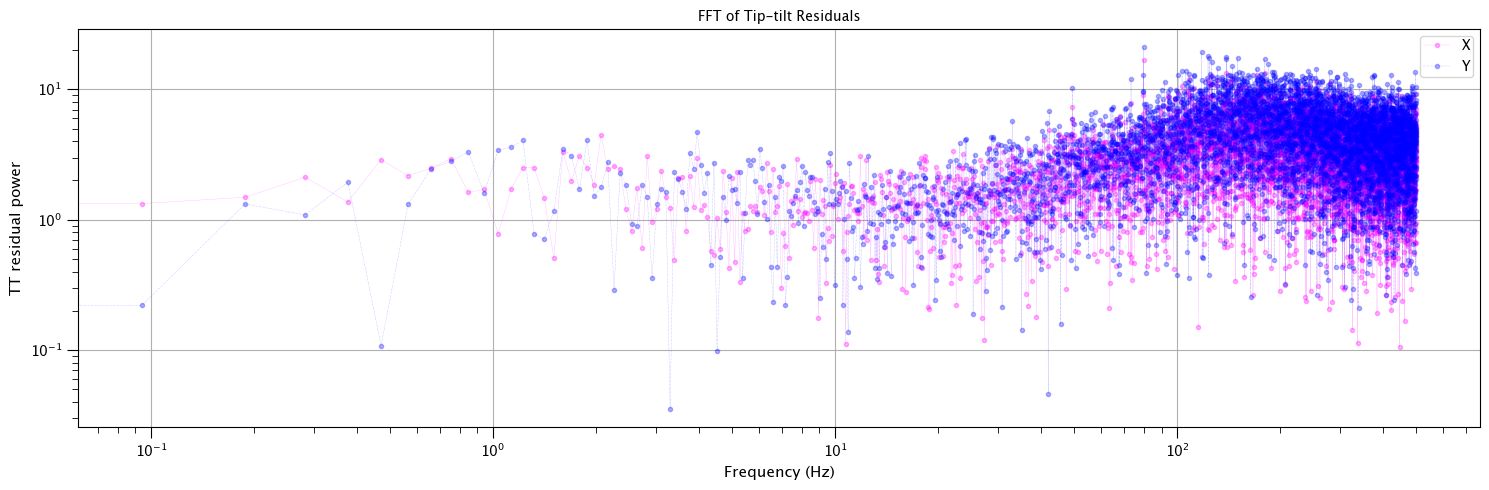

In [243]:
plt.figure(figsize=(15, 5))
plt.loglog(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.loglog(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()

**Fourier Transform of TT residual data from 'RESIDUALWAVEFRONT' keyword**

as opposed to RESIDUALRMS keyword

In [244]:
# Fourier transform TT centroids y
n = len(tt_residual)
# Real Fourier transform TT centroids (y) into frequency space
tt_residual_fft = np.fft.rfft(tt_residual)
print(tt_residual_fft.shape)
tt_residual_fft.shape
# Grab real (non-negative) frequencies
freq = np.fft.fftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)

(42516, 1)


In [245]:
print(tt_residual.shape)
print(tt_residual_fft.shape)
print(freq.shape)

(42516, 1)
(42516, 1)
(42516,)


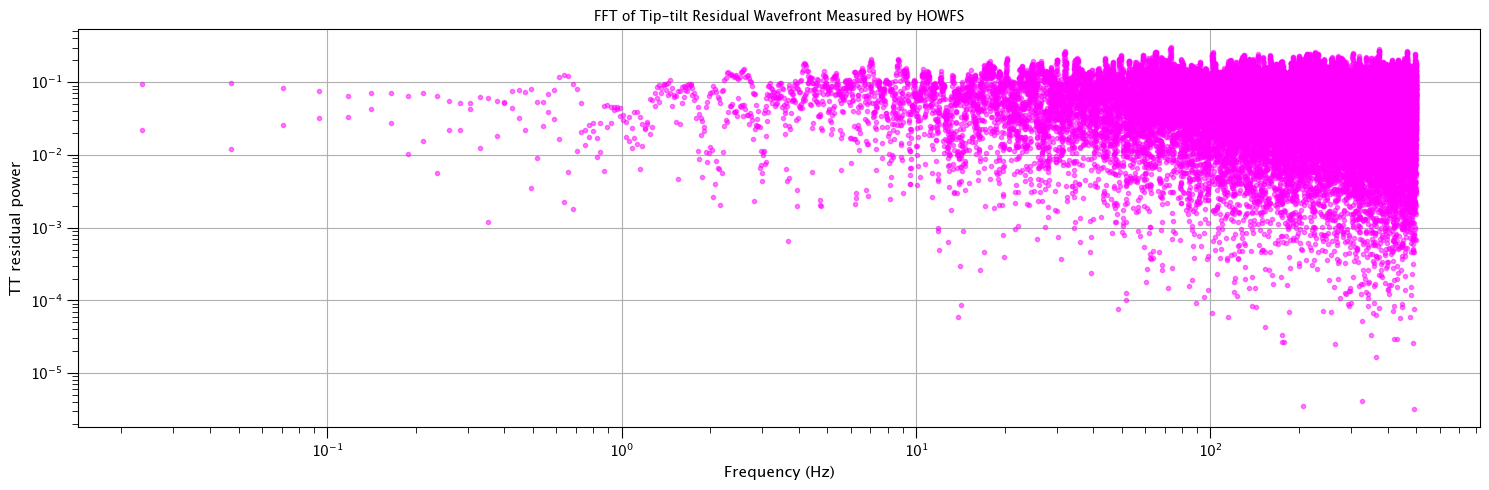

In [246]:
plt.figure(figsize=(15, 5))
plt.loglog(np.abs(freq), np.abs(tt_residual_fft), '.', linewidth=0.25, color="magenta", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residual Wavefront Measured by HOWFS")
plt.grid(True)
plt.tight_layout()

**Log-Linear Versions of Plots**

ValueError: x and y must have same first dimension, but have shapes (21259,) and (5315,)

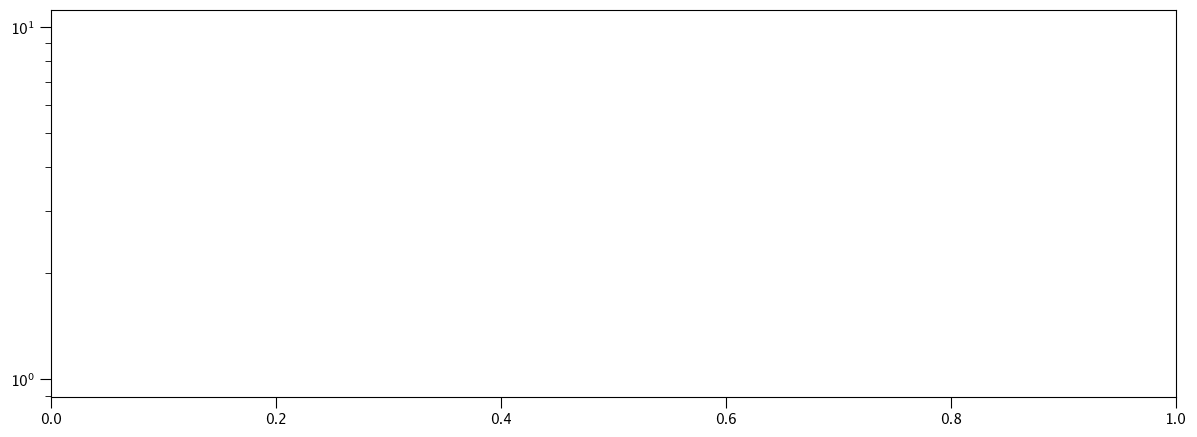

In [247]:
freq = np.fft.rfftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()

Zoom in on lower frequencies

ValueError: x and y must have same first dimension, but have shapes (21259,) and (5315,)

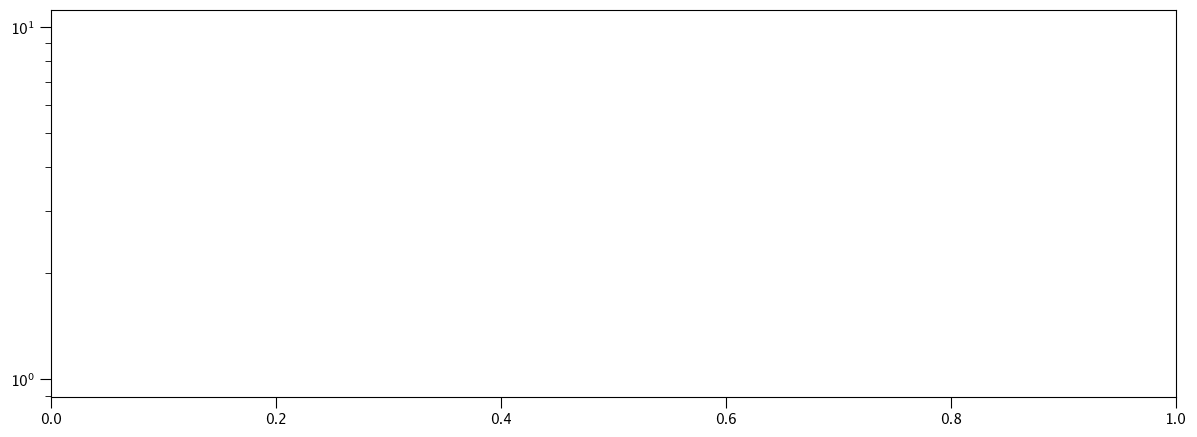

In [248]:
freq = np.fft.rfftfreq(n, d=0.001)
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(0, 100.0)

**Average Power Spectra**

ValueError: x and y must have same first dimension, but have shapes (21259,) and (5315,)

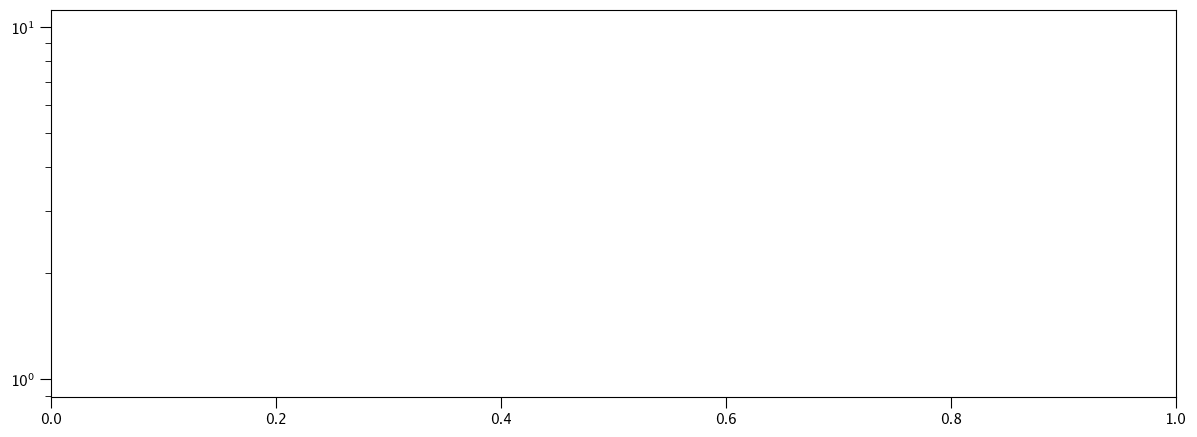

In [249]:
ttcentroids_fft = np.mean( [np.abs(ttcentroids_fftx), np.abs(ttcentroids_ffty)], axis=0)
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.semilogy(freq, ttcentroids_fft, '.-', linewidth=0.5, color='gold', alpha=0.3, label="Avg")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(0, 100.0)

(0.0, 100.0)

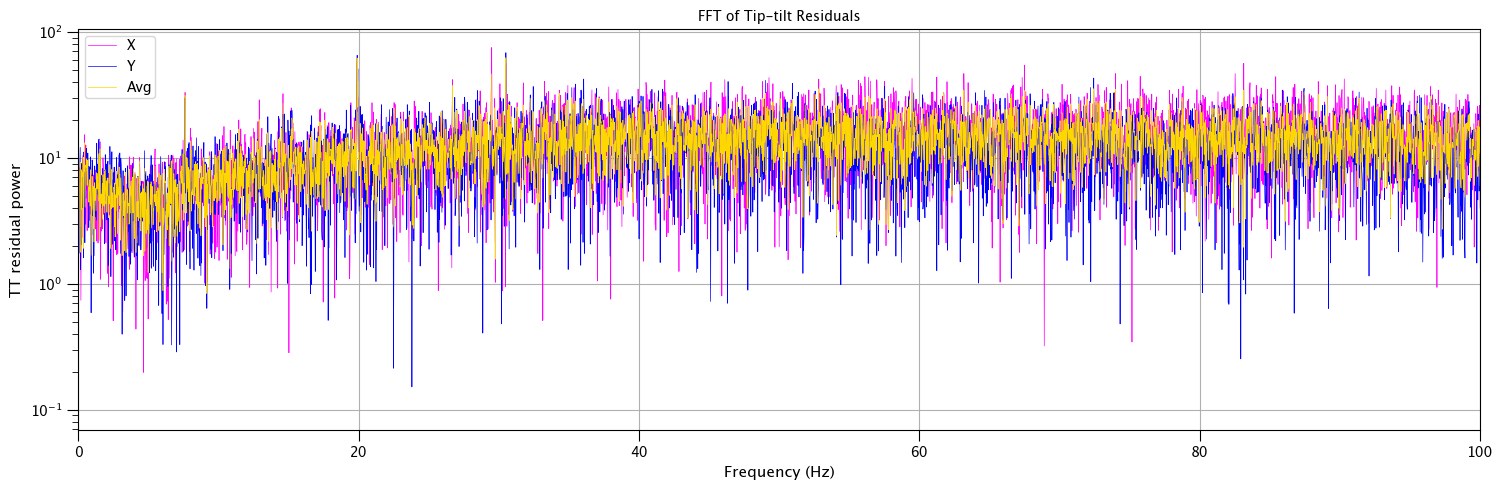

In [201]:
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), linewidth=0.5, color="magenta", label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), linewidth=0.5, color="blue", label="Y")
plt.semilogy(freq, ttcentroids_fft, linewidth=0.5, color='gold', label="Avg")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(0, 100.0)

**Pseudo Open Loop vs Closed Loop**

DTTCOMMANDS are 'down' tip-tilt actuator commands in absolute offsets (arcseconds)

TTCOMMANDS are laser tip-tilt actuator commands --> TT signal coming from the fast, HOWFS (arcsec)

In [250]:
dtt_commands = data.b.dttcommands[0]
tt_commands = data.a.ttcommands[0]

In [251]:
dtt_commands_x = dtt_commands[:,0]
dtt_commands_y = dtt_commands[:,1]
tt_commands_x = tt_commands[:,0]
tt_commands_y = tt_commands[:,1]

In [252]:
# Add commands to centroids = offsets to create pseudo open loop (pol)
# measurement (arrays should be aligned and same length despite time
# lag between entering of command and execution by actuator)
dtt_pol_x = np.add(dtt_commands_x, ttcentroids_x)
dtt_pol_y = np.add(dtt_commands_y, ttcentroids_y)
tt_pol_x = np.add(tt_commands_x, ttcentroids_x)
tt_pol_y = np.add(tt_commands_y, ttcentroids_y)
print(dtt_pol_x.shape, dtt_pol_y.shape, tt_pol_x.shape, tt_pol_y.shape)

ValueError: operands could not be broadcast together with shapes (42516,) (10629,) 

ValueError: x and y must have same first dimension, but have shapes (10629,) and (42516,)

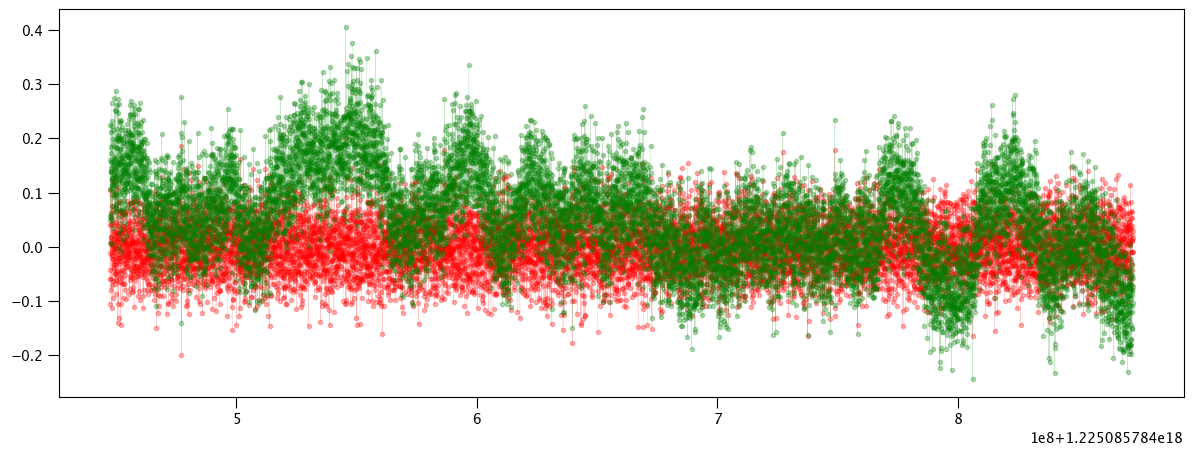

In [253]:
plt.figure(figsize=(15, 5))
plt.plot(data.b.timestamp[0], ttcentroids_x, '.-', linewidth=0.25, color="red", alpha=0.3, label="CL TT X")
plt.plot(data.b.timestamp[0], dtt_pol_x, '.-', linewidth=0.25, color="green", alpha=0.3, label="Down POL TT X")
plt.plot(data.b.timestamp[0], tt_pol_x, '.-', linewidth=0.25, color="violet", alpha=0.3, label="HOWFS POL TT X")
plt.xlabel("Time (s)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) X Measurements (Arcsec)")
plt.grid(True)
plt.tight_layout()
plt.legend()

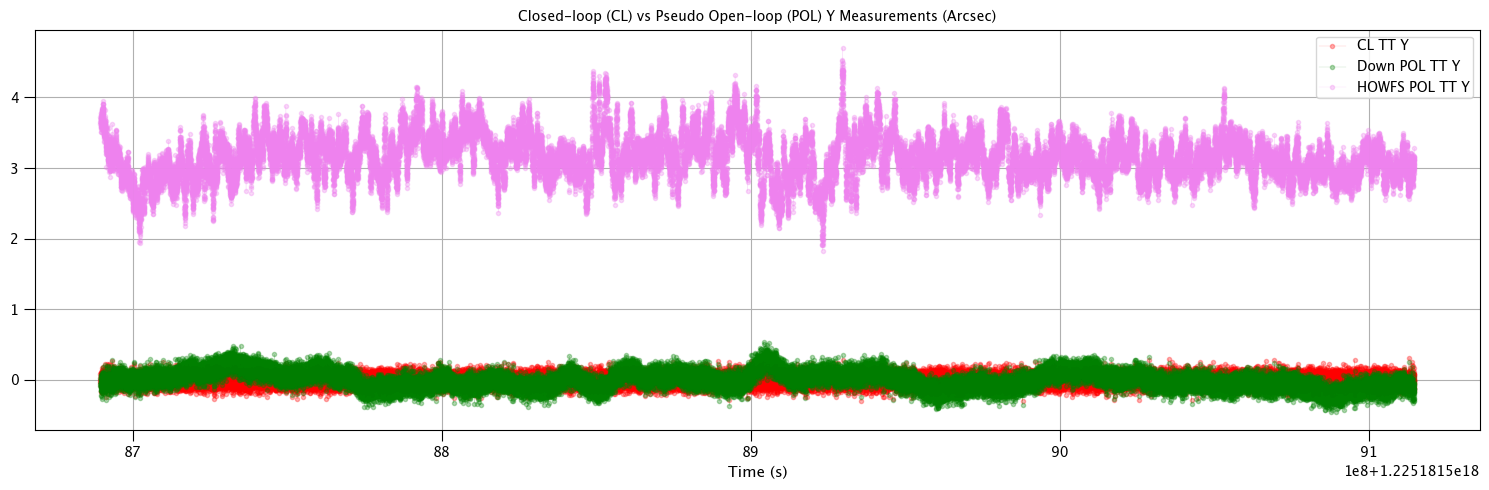

In [66]:
plt.figure(figsize=(15, 5))
plt.plot(data.b.timestamp[0], ttcentroids_y, '.-', linewidth=0.25, color="red", alpha=0.3, label="CL TT Y")
plt.plot(data.b.timestamp[0], dtt_pol_y, '.-', linewidth=0.25, color="green", alpha=0.3, label="Down POL TT Y")
plt.plot(data.b.timestamp[0], tt_pol_y, '.-', linewidth=0.25, color="violet", alpha=0.3, label="HOWFS POL TT Y")
plt.xlabel("Time (s)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Y Measurements (Arcsec)")
plt.grid(True)
plt.tight_layout()
plt.legend()

In [67]:
# Fourier transform pseudo open loop measurement
nx = len(tt_pol_x)
ny = len(tt_pol_y)
dnx = len(dtt_pol_x)
dny = len(dtt_pol_y)

# Real Fourier transform TT centroids (y) into frequency space
dtt_pol_fftx = np.fft.rfft(dtt_pol_x)
dtt_pol_ffty = np.fft.rfft(dtt_pol_y)
tt_pol_fftx = np.fft.rfft(tt_pol_x)
tt_pol_ffty = np.fft.rfft(tt_pol_y)
# Grab real (non-negative) frequencies
freq = np.fft.rfftfreq(nx, d=0.001)

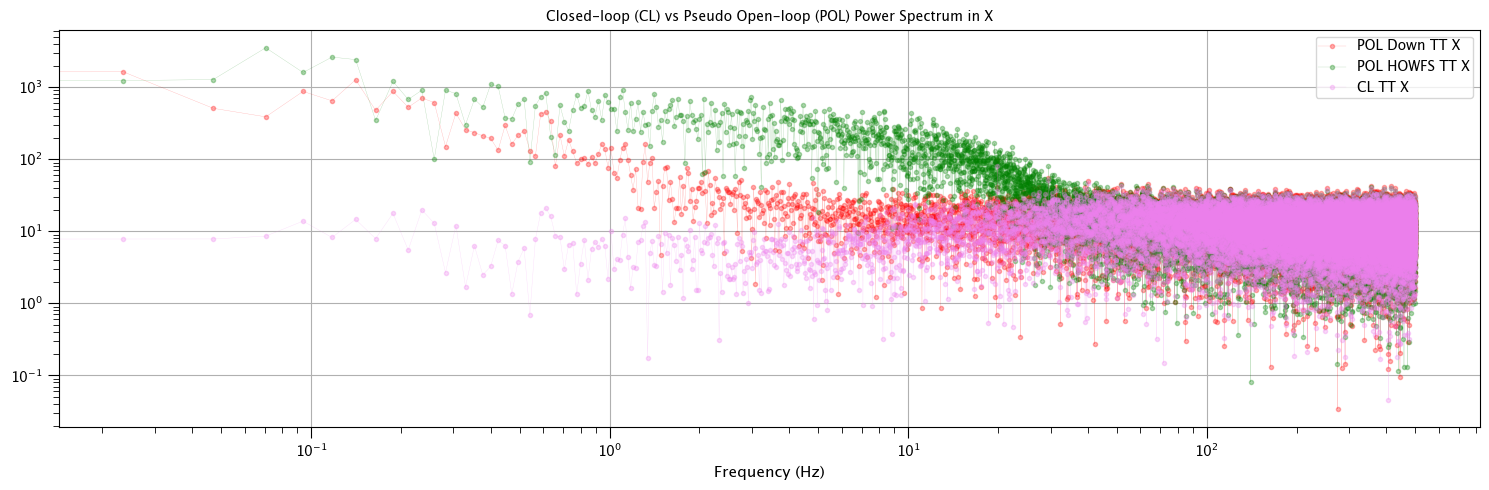

In [68]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.loglog(freq, np.abs(dtt_pol_fftx), '.-', linewidth=0.25, color="red", alpha=0.3, label="POL Down TT X")
plt.loglog(freq, np.abs(tt_pol_fftx), '.-', linewidth=0.25, color="green", alpha=0.3, label="POL HOWFS TT X")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.loglog(freq, np.abs(ttcentroids_fftx), '.-', linewidth=0.25, color="violet", alpha=0.3, label="CL TT X")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in X")
plt.grid(True)
plt.tight_layout()
plt.legend()

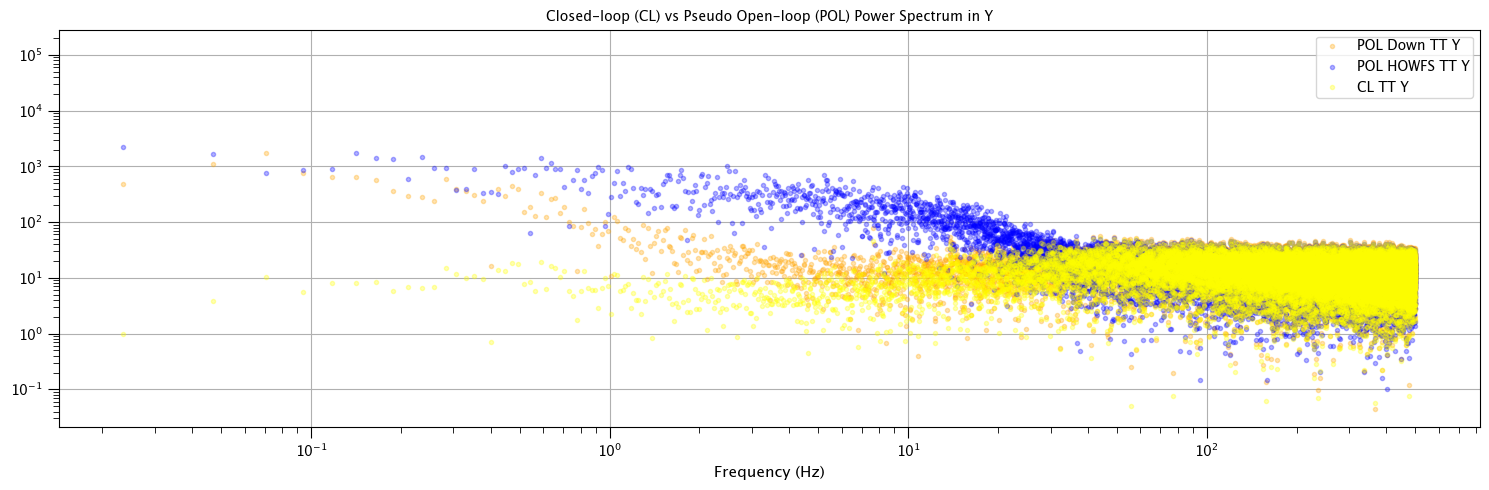

In [69]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.loglog(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.loglog(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.loglog(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

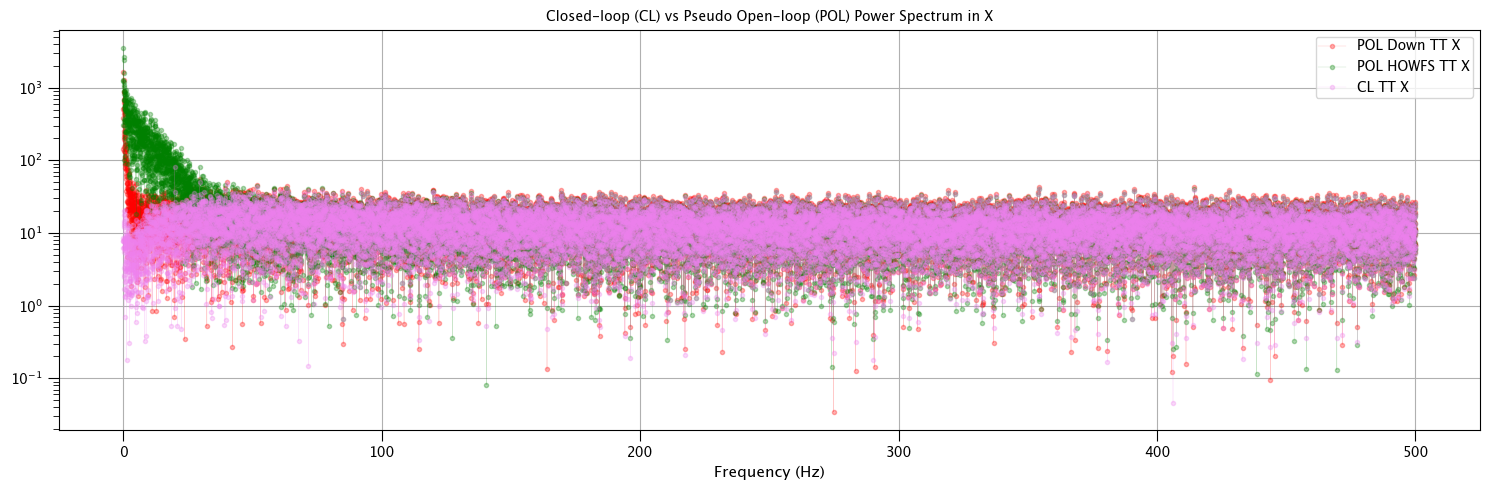

In [70]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_fftx), '.-', linewidth=0.25, color="red", alpha=0.3, label="POL Down TT X")
plt.semilogy(freq, np.abs(tt_pol_fftx), '.-', linewidth=0.25, color="green", alpha=0.3, label="POL HOWFS TT X")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-', linewidth=0.25, color="violet", alpha=0.3, label="CL TT X")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in X")
plt.grid(True)
plt.tight_layout()
plt.legend()

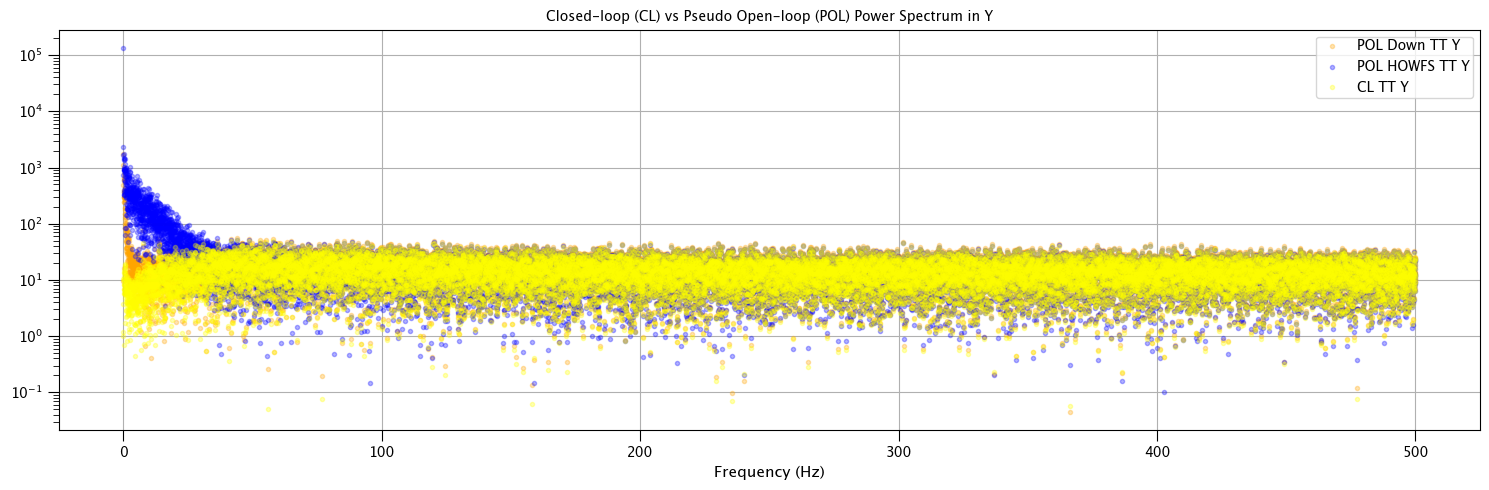

In [71]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.semilogy(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

Where does break in power spectra occur?

Elbow using pseudo-open-loop curve: 59.201241885407846 Hz
Knee using closed-loop curve: 53.41518487157776 Hz


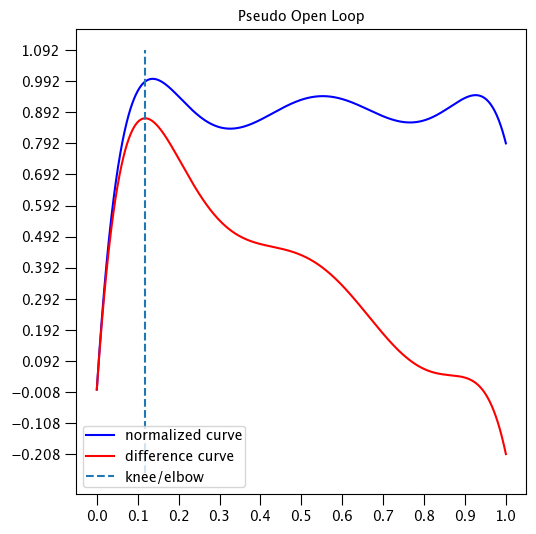

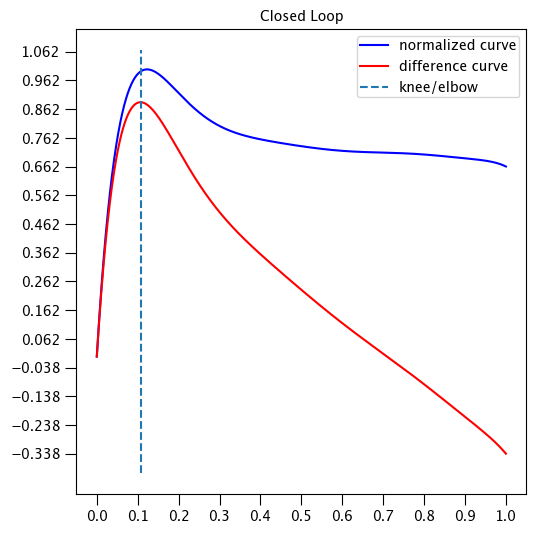

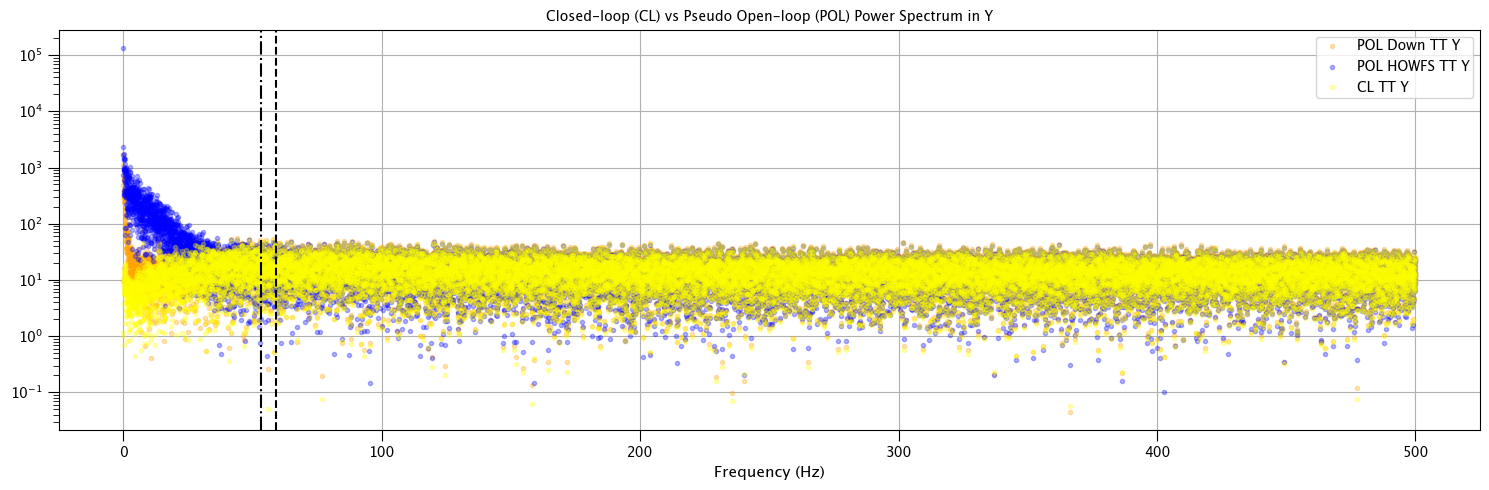

In [126]:
# indices = np.argsort(freq)[:100]
# S = Sensitivity = 1.0 as suggested by kneed docs, concave curve to locate knee point, increasing direction for positive slope
kneedle_pol = kneed.KneeLocator(freq, np.abs(tt_pol_ffty), S=1.0, curve='convex', 
                            direction='decreasing', interp_method='polynomial', 
                            polynomial_degree=6)
kneedle_cl = kneed.KneeLocator(freq, np.abs(ttcentroids_ffty), S=1.0, curve='concave', 
                            direction='increasing', interp_method='polynomial', 
                            polynomial_degree=8)
elbow = kneedle_pol.elbow # the returned knee point is the value on the x-axis (frequency)
print(f'Elbow using pseudo-open-loop curve: {elbow} Hz')
knee = kneedle_cl.knee
print(f'Knee using closed-loop curve: {knee} Hz')
kneedle_pol.plot_knee_normalized(title='Pseudo Open Loop')
kneedle_cl.plot_knee_normalized(title='Closed Loop')

plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.semilogy(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.axvline(x=elbow, linestyle='--', color='black')
plt.axvline(x=knee, linestyle='-.', color='black')
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

In [35]:
data.a.subapintensity[0].shape

(42516, 304)

In [36]:
# Average subaperture intensities over time for 304 sub apertures (units = adu)
np.mean(data.a.subapintensity[0], axis=0)

array([  79.52618 ,   78.45272 ,   89.69138 ,   82.9073  ,  259.3567  ,
        192.7016  ,  123.64068 ,  587.31805 ,  141.52203 ,  610.43286 ,
       1238.6692  ,  783.9682  , 1857.9037  , 1971.1002  ,  424.35327 ,
         74.91495 , 1340.1675  , 1105.4551  , 1374.4176  , 1986.8557  ,
       1541.1963  , 1983.8821  , 2052.1128  , 1921.0317  , 2139.0278  ,
       2176.5122  ,  947.9889  ,   85.75858 ,   69.57254 ,   63.114594,
       1159.5913  , 2017.3113  , 2200.2483  , 2084.2527  , 2091.8713  ,
       2045.102   , 1883.4402  , 1967.4791  , 1983.5062  , 2110.1929  ,
       1842.7986  , 1392.7755  ,  936.9348  ,  119.025826,   64.796715,
         57.577713,  987.1296  , 2036.0365  , 2093.759   , 2113.4902  ,
       2083.9597  , 2001.5552  , 1871.3346  , 1992.4778  , 2143.8276  ,
       2114.4443  , 1631.7799  , 1347.0704  , 1406.6053  ,  296.6721  ,
         69.6169  ,   60.612923,  701.515   , 1863.2529  , 1991.2389  ,
       2065.625   , 2146.0266  , 2068.5024  , 2155.1711  , 1983.

Text(0.5, 1.0, 'Time-averaged sub aperture intensities for 304 subapertures')

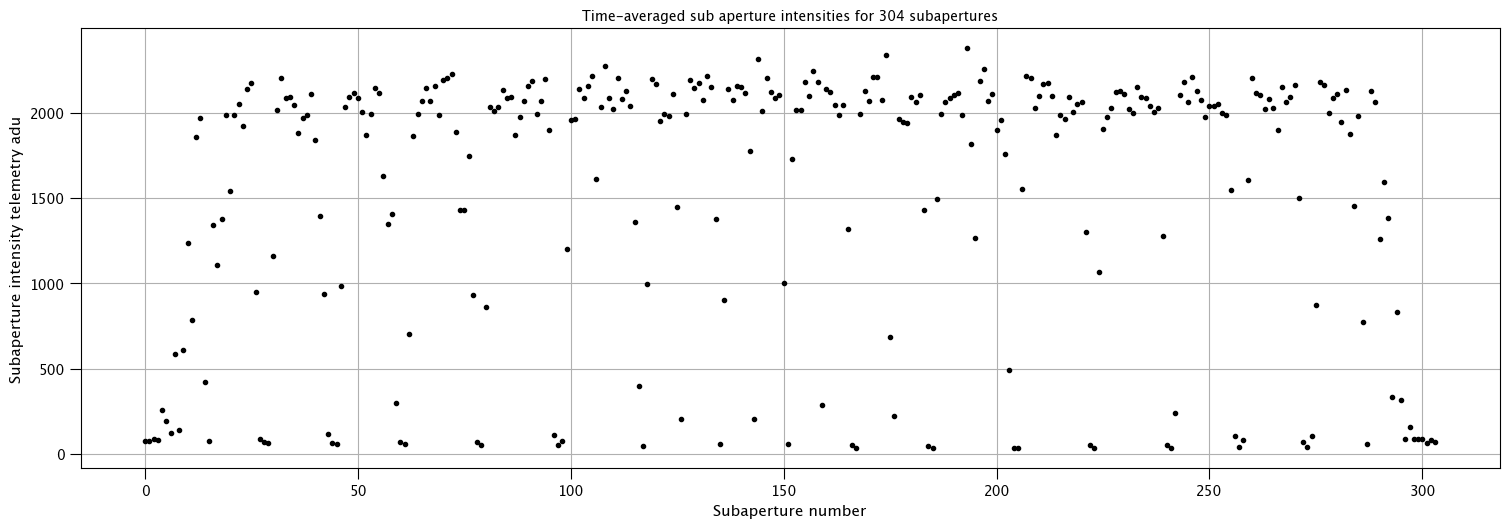

In [37]:
plt.figure(figsize=(15, 5))
plt.plot(np.mean(data.a.subapintensity[0], axis=0), '.', color='k')
plt.grid(True)
plt.tight_layout()
plt.xlabel("Subaperture number")
plt.ylabel("Subaperture intensity telemetry adu")
plt.title("Time-averaged sub aperture intensities for 304 subapertures")

In [38]:
avg_subapint = np.mean(data.a.subapintensity[0], axis=0)
sorted_indices = np.argsort(avg_subapint)
avg_subapint[sorted_indices][::-1]

array([2376.223   , 2337.091   , 2315.139   , 2271.169   , 2254.5125  ,
       2244.5112  , 2227.3892  , 2216.3699  , 2215.5781  , 2213.6829  ,
       2211.5337  , 2211.2168  , 2207.686   , 2204.4468  , 2202.3713  ,
       2200.8906  , 2200.8066  , 2200.4414  , 2200.2483  , 2199.153   ,
       2197.5166  , 2192.437   , 2189.3137  , 2186.1023  , 2185.4695  ,
       2181.951   , 2180.3315  , 2180.1711  , 2178.4492  , 2176.568   ,
       2176.5122  , 2171.05    , 2170.2385  , 2165.9397  , 2164.4026  ,
       2162.3213  , 2158.2668  , 2155.5813  , 2155.1711  , 2154.282   ,
       2152.2166  , 2151.7395  , 2149.6748  , 2149.5337  , 2146.0266  ,
       2143.8276  , 2142.689   , 2140.776   , 2139.2996  , 2139.0278  ,
       2135.73    , 2134.5037  , 2133.296   , 2126.573   , 2125.0942  ,
       2124.7703  , 2124.7324  , 2124.196   , 2121.6753  , 2121.128   ,
       2119.187   , 2115.4512  , 2115.425   , 2114.4443  , 2113.4902  ,
       2112.9983  , 2112.282   , 2110.1929  , 2109.4297  , 2106.

**10 Brightest Subapertures**

In [39]:
print(avg_subapint[sorted_indices][::-1][0:10])
print(sorted_indices[0:10])

[2376.223  2337.091  2315.139  2271.169  2254.5125 2244.5112 2227.3892
 2216.3699 2215.5781 2213.6829]
[205 241 223 167 185 204 273 257 184 117]


---------------------------

In [40]:
skyroot = Path("/Users/bdigia/work/ao/airopa_input/")
dates = [f.as_posix()[-16:-8] for f in skyroot.glob("*/")]
names = []
datecol = []
sky_paths = []
for date in dates:
    name = [f.as_posix()[-14:-9] for f in skyroot.glob(f"{date}nirc2_kp/*_psf.fits")]
    paths = [f.as_posix() for f in skyroot.glob(f"{date}nirc2_kp/*_psf.fits")]
    names.extend(name)
    temp = np.full(len(name), date)
    datecol.extend(temp.tolist())
    sky_paths.extend(paths)
names = np.array(names)
datecol = np.array(datecol)    
namesanddates = np.column_stack((names, datecol))

In [3]:
from maos_utils import calc_strehl
from astropy.io import fits

# milliseconds 
strap_times = []
shwfs_times = []
skylist = []
maos_strehls = []
maos_fwhms = []
seeds = [1, 1000, 5000, 10000]
for i, sky in enumerate(namesanddates):
    sky_file = skyroot.as_posix() + f"/{sky[1]}nirc2_kp/{sky[0]}_psf.fits"
    sky_folder = skyroot.as_posix() + f"/{sky[1]}nirc2_kp/"

    # Grab sky FITS file header
    with fits.open(sky_file) as fits_file:
        hdu = fits_file[0]
        hdr = hdu.header
        # STRAP WFS integration time (milli-sec)
        try:
            hdr_strap_int_time = float(hdr['STINTTIM'])

            strehls_to_avg = []
            fwhms_to_avg = []
            for seed in seeds:
                maos_seed_strehls, maos_seed_fwhms, _ = calc_strehl(f"/Users/bdigia/work/ao/keck/maos/keck/my_base/PSD_NCPA_seen_before_03312024/A_keck_scao_lgs_gc_comp_{sky[0]}_seed{seed}_epoch{sky[1]}/", "temp2.txt", sim_seed=seed)
                strehls_to_avg.append(maos_seed_strehls[-1])
                fwhms_to_avg.append(maos_seed_fwhms[-1])
            maos_strehls.append(np.mean(strehls_to_avg))
            maos_fwhms.append(np.mean(fwhms_to_avg))
            skylist.append(sky_file)

        except KeyError as error:
            # print(f"Excluding {sky_file} from graph")
            continue
        except IndexError as error:
            continue

        # Frame rate for WFS cam (Hz)
        hdr_shwfs_frame_rate = float(hdr['WSFRRT'])
        hdr_shwfs_int_time = (1.0/hdr_shwfs_frame_rate)*1000.0
        strap_times.append(hdr_strap_int_time)
        shwfs_times.append(hdr_shwfs_int_time)

In [4]:
# sim.dt equal for STRAP and SHWFS --> equal int time in config file
maos_strap_shwfs_int_time = np.full(len(strap_times), (1.0/472.0)*1000.0) # milliseconds
strap_int_diff = np.abs(np.subtract(strap_times, maos_strap_shwfs_int_time))
shwfs_int_diff = np.abs(np.subtract(shwfs_times, maos_strap_shwfs_int_time))

In [5]:
# Compute metrics on sky list
from maos_utils import calc_strehl_on_sky
sky_strehls, sky_fwhms, sky_rmswfes = calc_strehl_on_sky(skylist, "temp.txt", apersize=0.6)

/Users/bdigia/work/ao/airopa_input/20110823nirc2_kp/c0021_psf.fits
Filter = Kp | Scale (arcsec/px) = 0.009952 | Wavelength (microns) = 2.124500 
dl_peak_flux_ratio: 0.036778376
c0021_psf.fits 1 5.689716142104249 85.026061079099 84.97664342249925 21.0
peak flux ratio =  0.011612734  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20110823nirc2_kp/c0021_psf.fits   0.316   363.0   56.62   85.0   85.0

c0021_psf.fits                   0.316   363.0   56.62  55796.2537

c0022_psf.fits 1 5.741866433017692 85.0078456695551 85.01363010564539 21.0
peak flux ratio =  0.010841206  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20110823nirc2_kp/c0022_psf.fits   0.295   373.7   57.14   85.0   85.0

c0022_psf.fits                   0.295   373.7   57.14  55796.2543

c0026_psf.fits 1 5.82729704164618 84.99388833521147 85.00251741484249 21.0
peak flux ratio =  0.009978083  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20110823nirc2_kp/c

In [6]:
strehl_diff = np.abs(np.subtract(sky_strehls, maos_strehls))
fwhm_diff = np.abs(np.subtract(sky_fwhms, maos_fwhms))

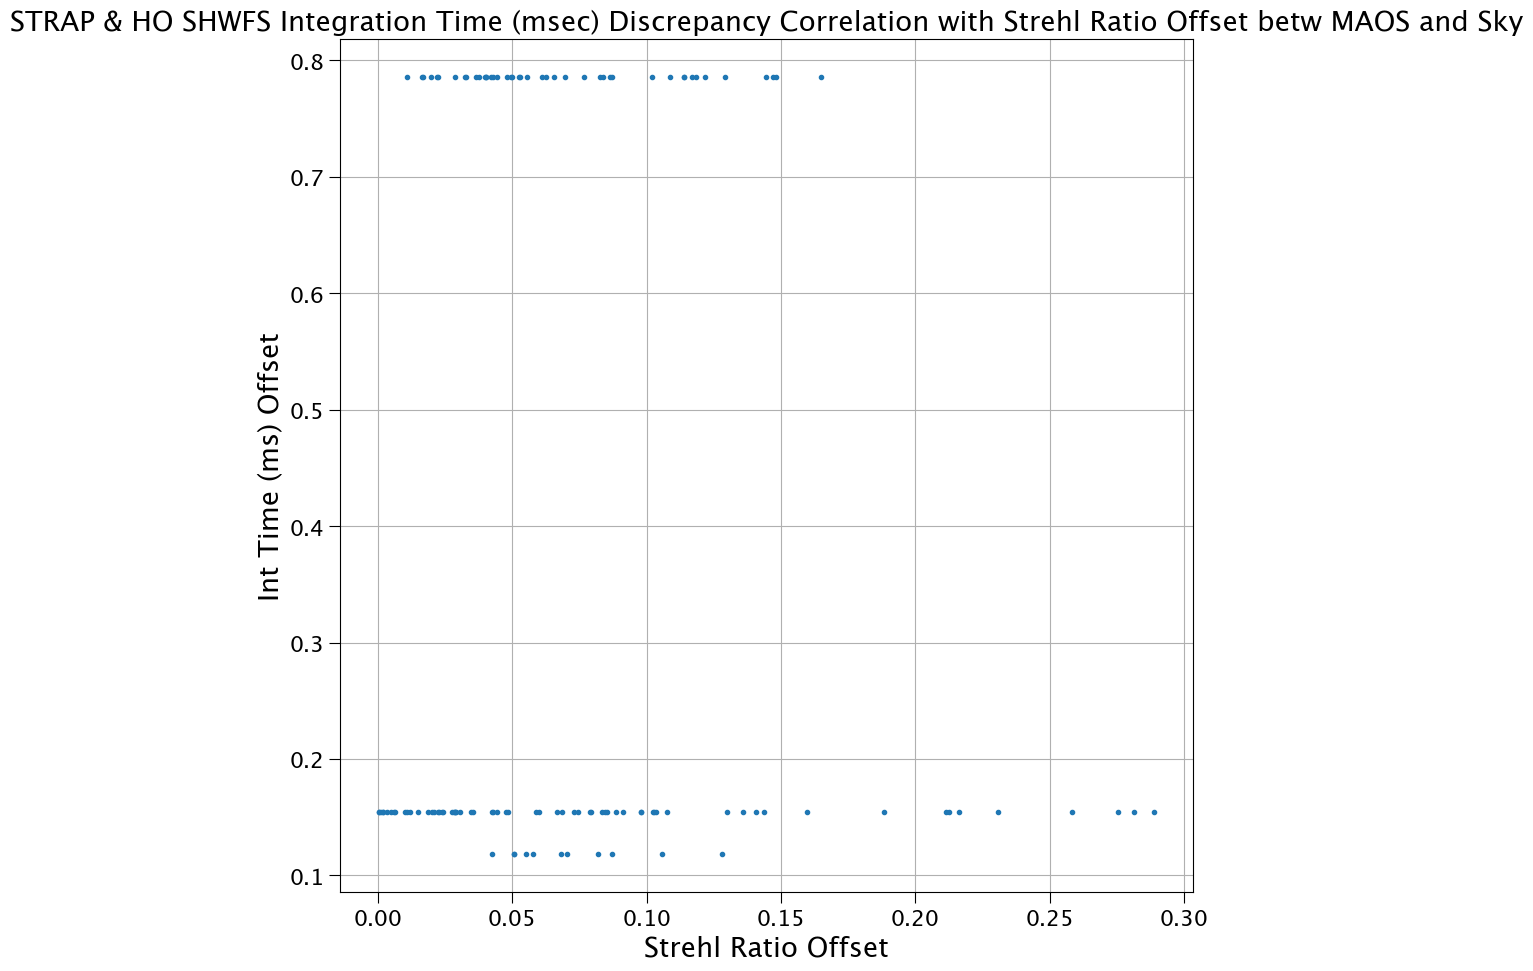

In [16]:
plt.figure(figsize=(10, 10))
# plt.plot(strehl_diff, ".", label="STRAP")
plt.plot(strehl_diff, shwfs_int_diff, ".", label="SHWFS")
plt.xlabel("Strehl Ratio Offset")
plt.ylabel("Int Time (ms) Offset")
plt.title("STRAP & HO SHWFS Integration Time (msec) Discrepancy Correlation with Strehl Ratio Offset betw MAOS and Sky")
plt.grid(True)
plt.tight_layout()